Code 3 cảm xúc

In [ ]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import re
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==========================================
# 2. LOAD DATASET
# ==========================================
file_path = "/content/data đồ án.xlsm"
df = pd.read_excel(file_path, engine="openpyxl")

df = df[["Comment", "Label"]].dropna()

print("Dataset shape:", df.shape)

# ==========================================
# 3. PREPROCESS TEXT
# ==========================================
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

df["clean_text"] = df["Comment"].apply(preprocess)

# ==========================================
# 4. ENCODE LABEL
# ==========================================
encoder = LabelEncoder()
y = encoder.fit_transform(df["Label"])   # POS, NEG, NEU → 0,1,2

# ==========================================
# 5. TOKENIZE TEXT
# ==========================================
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df["clean_text"])

X = tokenizer.texts_to_sequences(df["clean_text"])
X = pad_sequences(X, maxlen=max_len)

# ==========================================
# 6. TRAIN TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# 7. BUILD RNN MODEL
# ==========================================
model = Sequential([
    Input(shape=(max_len,)),                     # 👈 fix lỗi unbuilt
    Embedding(input_dim=max_words, output_dim=128),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 8. TRAIN MODEL
# ==========================================
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

# ==========================================
# 9. EVALUATE
# ==========================================
loss, acc = model.evaluate(X_test, y_test)
print("\n==== RNN MODEL ====")
print("\nAccuracy:", acc)

# ==========================================
# 10. PREDICT + REPORT
# ==========================================
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Dataset shape: (31460, 2)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,294,531 (4.94 MB)

 Trainable params: 1,294,531 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
354/354 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.7365 - loss: 0.6349 - val_accuracy: 0.7922 - val_loss: 0.5140
Epoch 2/5
354/354 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.8092 - loss: 0.4801 - val_accuracy: 0.7938 - val_loss: 0.5157
Epoch 3/5
354/354 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.8580 - loss: 0.3837 - val_accuracy: 0.7811 - val_loss: 0.5626
Epoch 4/5
354/354 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.8934 - loss: 0.2998 - val_accuracy: 0.7620 - val_loss: 0.6124
Epoch 5/5
354/354 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.9147 - loss: 0.2483 - val_accuracy: 0.7517 - val_loss: 0.6926
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7459 - loss: 0.7389

==== RNN MODEL ====

Accuracy: 0.7458677887916565
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

Confusion Matrix:
[[ 885  276  172]
 [ 283  269  426]
 [ 210  232 3539]]

Classification Report:
              precision    recall  f1-score   support

         NEG       0.64      0.66  

IMPORT LIBRARIES

In [ ]:
import pandas as pd
import re
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM,
    Dense, Dropout, SpatialDropout1D,
    BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

LOAD DATASET

In [ ]:
file_path = "/content/data-đồ-án.xlsm"

df = pd.read_excel(file_path, engine="openpyxl")

df = df[["Comment", "Label"]].dropna()
df["Label"] = df["Label"].astype(str).str.strip().str.upper()

print("Dataset shape:", df.shape)

print("\nLabel distribution:")
print(df["Label"].value_counts())

display(df.head())

Dataset shape: (31460, 2)

Label distribution:
Label
POS    20093
NEG     6669
NEU     4698
Name: count, dtype: int64


,Comment,Label
0,Áo bao đẹp ạ!!,POS
1,Tuyệt vời !,POS
2,2day ao khong giong trong.,NEG
3,"Mùi thơm,bôi lên da mềm da.",POS
4,"Vải đẹp, dày dặn.",POS


TEXT PREPROCESSING

In [ ]:
def preprocess(text):
    text = str(text).lower()

    replacements = {
        " ko ": " không ",
        " k ": " không ",
        " kh ": " không ",
        " hok ": " không ",
        " kg ": " không ",
        " dc ": " được ",
        " đc ": " được ",
        " sp ": " sản phẩm ",
        " ok ": " tốt ",
        " oke ": " tốt ",
    }

    text = " " + text + " "
    for k, v in replacements.items():
        text = text.replace(k, v)

    # Giữ chữ tiếng Việt, số và khoảng trắng
    text = re.sub(r"[^\w\sÀ-ỹ]", " ", text)

    # Giảm ký tự lặp: đẹpppp -> đẹpp
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Chuẩn hóa khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["Comment"].apply(preprocess)

display(df[["Comment", "clean_text", "Label"]].head())

,Comment,clean_text,Label
0,Áo bao đẹp ạ!!,áo bao đẹp ạ,POS
1,Tuyệt vời !,tuyệt vời,POS
2,2day ao khong giong trong.,2day ao khong giong trong,NEG
3,"Mùi thơm,bôi lên da mềm da.",mùi thơm bôi lên da mềm da,POS
4,"Vải đẹp, dày dặn.",vải đẹp dày dặn,POS


ENCODE LABELS

In [ ]:
encoder = LabelEncoder()
y = encoder.fit_transform(df["Label"])

print("Label mapping:")
for idx, label in enumerate(encoder.classes_):
    print(idx, "=>", label)

Label mapping:
0 => NEG
1 => NEU
2 => POS


TOKENIZATION AND PADDING

In [ ]:
max_words = 30000
max_len = 80

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df["clean_text"])

X = tokenizer.texts_to_sequences(df["clean_text"])

X = pad_sequences(
    X,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print("X shape:", X.shape)
print("Example sequence:", X[0])

X shape: (31460, 80)
Example sequence: [ 12 208   5  53   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0]


 TRAIN / TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 25168
Test size: 6292


BUILD RNN MODEL
Bidirectional LSTM for Emotion Classification

In [ ]:
embedding_dim = 128

inputs = Input(shape=(max_len,))

x = Embedding(
    input_dim=max_words,
    output_dim=embedding_dim
)(inputs)

x = SpatialDropout1D(0.2)(x)

x = Bidirectional(
    LSTM(
        64,
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)(x)

x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)

outputs = Dense(3, activation="softmax")(x)

model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 80, 128)        │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 80, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,964,291 (15.12 MB)

 Trainable params: 3,964,035 (15.12 MB)

 Non-trainable params: 256 (1.00 KB)

COMPILE MODEL

In [ ]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


 CALLBACKS

In [ ]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    mode="max",
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Callbacks created.")

Callbacks created.


TRAIN MODEL

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 122s 317ms/step - accuracy: 0.6975 - loss: 0.7042 - val_accuracy: 0.7275 - val_loss: 0.6917 - learning_rate: 5.0000e-04
Epoch 2/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 113s 318ms/step - accuracy: 0.7801 - loss: 0.5492 - val_accuracy: 0.7831 - val_loss: 0.5295 - learning_rate: 5.0000e-04
Epoch 3/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 142s 318ms/step - accuracy: 0.7990 - loss: 0.5049 - val_accuracy: 0.7835 - val_loss: 0.5521 - learning_rate: 5.0000e-04
Epoch 4/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.8176 - loss: 0.4637
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
354/354 ━━━━━━━━━━━━━━━━━━━━ 114s 320ms/step - accuracy: 0.8125 - loss: 0.4722 - val_accuracy: 0.7894 - val_loss: 0.5322 - learning_rate: 5.0000e-04
Epoch 5/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 112s 315ms/step - accuracy: 0.8299 - loss: 0.4322 - val_accuracy: 0.7914 - val_loss: 0.5362 - learning_rate: 2.5000e-04
Epoch 6/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 309m

In [ ]:
# ==========================================
# CLASSIFICATION REPORT AFTER TRAINING
# ==========================================

import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(y_test, y_pred)

print("==== RNN / BiLSTM MODEL REPORT ====")
print(f"Test Accuracy: {acc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_,
        digits=4
    )
)

==== RNN / BiLSTM MODEL REPORT ====
Test Accuracy: 0.7816

Confusion Matrix:
[[1051  155  128]
 [ 352  200  387]
 [ 199  153 3667]]

Classification Report:
              precision    recall  f1-score   support

         NEG     0.6561    0.7879    0.7159      1334
         NEU     0.3937    0.2130    0.2764       939
         POS     0.8769    0.9124    0.8943      4019

    accuracy                         0.7816      6292
   macro avg     0.6422    0.6378    0.6289      6292
weighted avg     0.7579    0.7816    0.7643      6292



CALCULATE Main Metric, Precision, Recall, F1-score, Params, FPS, Parameters, Model Size, FLOPs, FPS / Inference Time

In [ ]:
import time
import os
import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# 1. PREDICT ON TEST SET
# ==========================================

y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# ==========================================
# 2. PERFORMANCE METRICS
# Main Metric = Accuracy
# Precision / Recall / F1-score = macro average
# ==========================================

main_metric = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

# ==========================================
# 3. PARAMS / PARAMETERS
# ==========================================

total_params = model.count_params()
params_million = total_params / 1_000_000

# ==========================================
# 4. MODEL SIZE
# ==========================================

model_path = "rnn_bilstm_emotion_model.keras"
model.save(model_path)

model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

# ==========================================
# 5. FPS / INFERENCE TIME
# ==========================================

# Warm-up để đo tốc độ ổn định hơn
_ = model.predict(X_test[:128], verbose=0)

start_time = time.time()
_ = model.predict(X_test, verbose=0)
end_time = time.time()

total_inference_time = end_time - start_time
num_samples = len(X_test)

fps = num_samples / total_inference_time
inference_time_ms = (total_inference_time / num_samples) * 1000

# ==========================================
# 6. ESTIMATE FLOPs
# Với RNN/BiLSTM, FLOPs tự động thường lỗi,
# nên dùng ước lượng đơn giản theo số parameters.
# ==========================================

flops = total_params * 2
flops_g = flops / 1_000_000_000

# ==========================================
# 7. PRINT VALUES ONLY
# ==========================================

print("Main Metric / Accuracy:", f"{main_metric:.4f}")
print("Precision:", f"{precision:.4f}")
print("Recall:", f"{recall:.4f}")
print("F1-score:", f"{f1:.4f}")

print("Params:", f"{params_million:.4f} M")
print("FPS:", f"{fps:.2f}")

print("Parameters:", f"{params_million:.4f} M")
print("Model Size:", f"{model_size_mb:.2f} MB")
print("FLOPs:", f"{flops_g:.6f} G")
print("FPS / Inference Time:", f"{fps:.2f} FPS / {inference_time_ms:.4f} ms")

Main Metric / Accuracy: 0.7816
Precision: 0.6422
Recall: 0.6378
F1-score: 0.6289
Params: 3.9643 M
FPS: 569.20
Parameters: 3.9643 M
Model Size: 45.43 MB
FLOPs: 0.007929 G
FPS / Inference Time: 569.20 FPS / 1.7569 ms


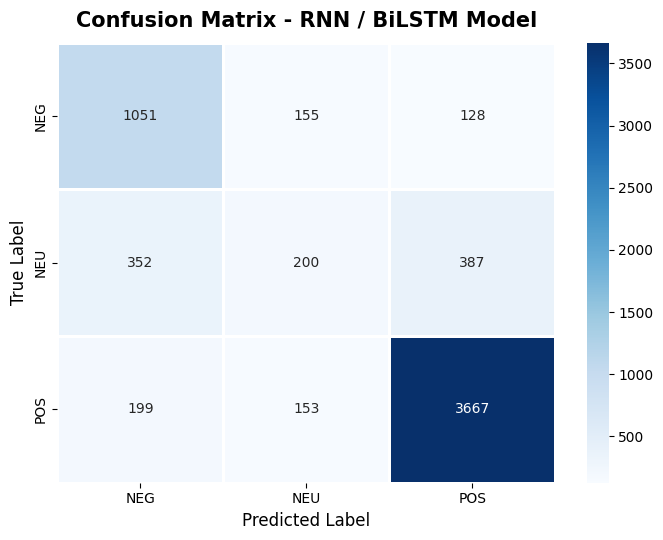

In [ ]:
# ==========================================
# PLOT CONFUSION MATRIX - RNN / BiLSTM MODEL
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. PREDICT ON TEST SET
# ==========================================

y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# ==========================================
# 2. CREATE CONFUSION MATRIX
# ==========================================

labels = encoder.classes_
cm = confusion_matrix(y_test, y_pred)

# ==========================================
# 3. PLOT CONFUSION MATRIX
# ==========================================

plt.figure(figsize=(7, 5.5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.8,
    linecolor="white",
    cbar=True
)

plt.title("Confusion Matrix - RNN / BiLSTM Model", fontsize=15, fontweight="bold", pad=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.show()

SAVE TRAINED RNN / BiLSTM MODEL

In [ ]:
import os
import pickle
import json

# ==========================================
# 1. CREATE SAVE FOLDER
# ==========================================

save_dir = "saved_rnn_model"
os.makedirs(save_dir, exist_ok=True)

# ==========================================
# 2. SAVE RNN / BiLSTM MODEL
# ==========================================

model_path = os.path.join(save_dir, "rnn_bilstm_emotion_model.keras")
model.save(model_path)

# ==========================================
# 3. SAVE TOKENIZER
# ==========================================

tokenizer_path = os.path.join(save_dir, "rnn_tokenizer.pkl")

with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

# ==========================================
# 4. SAVE LABEL ENCODER
# ==========================================

encoder_path = os.path.join(save_dir, "rnn_label_encoder.pkl")

with open(encoder_path, "wb") as f:
    pickle.dump(encoder, f)

# ==========================================
# 5. SAVE CONFIG
# ==========================================

config = {
    "max_words": max_words,
    "max_len": max_len,
    "labels": encoder.classes_.tolist()
}

config_path = os.path.join(save_dir, "rnn_config.json")

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=4)

# ==========================================
# 6. CHECK SAVED FILES
# ==========================================

print("1.", model_path)
print("2.", tokenizer_path)
print("3.", encoder_path)
print("4.", config_path)

print("\nDanh sách file trong thư mục saved_rnn_model:")
print(os.listdir(save_dir))

1. saved_rnn_model/rnn_bilstm_emotion_model.keras
2. saved_rnn_model/rnn_tokenizer.pkl
3. saved_rnn_model/rnn_label_encoder.pkl
4. saved_rnn_model/rnn_config.json

Danh sách file trong thư mục saved_rnn_model:
['rnn_label_encoder.pkl', 'rnn_tokenizer.pkl', 'rnn_bilstm_emotion_model.keras', 'rnn_config.json']
